In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [13]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [14]:
df = pd.read_csv('german_credit_data_updated.csv', index_col=0)

In [8]:
print("Dataset Shape:", df.shape)

Dataset Shape: (954, 11)


In [15]:
print(f"\nColumns: {list(df.columns)}")


Columns: ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Credit Risk']


In [10]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,1
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,2
2,2,49,male,1,own,little,NaN,2096,12,education,1
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,4,53,male,2,free,little,little,4870,24,car,2


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 954 entries, 0 to 953
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               954 non-null    int64 
 1   Sex               954 non-null    object
 2   Job               954 non-null    int64 
 3   Housing           954 non-null    object
 4   Saving accounts   779 non-null    object
 5   Checking account  576 non-null    object
 6   Credit amount     954 non-null    int64 
 7   Duration          954 non-null    int64 
 8   Purpose           954 non-null    object
 9   Credit Risk       954 non-null    int64 
dtypes: int64(5), object(5)
memory usage: 82.0+ KB


In [17]:
print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)


EXPLORATORY DATA ANALYSIS


In [18]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     175
Checking account    378
Credit amount         0
Duration              0
Purpose               0
Credit Risk           0
dtype: int64


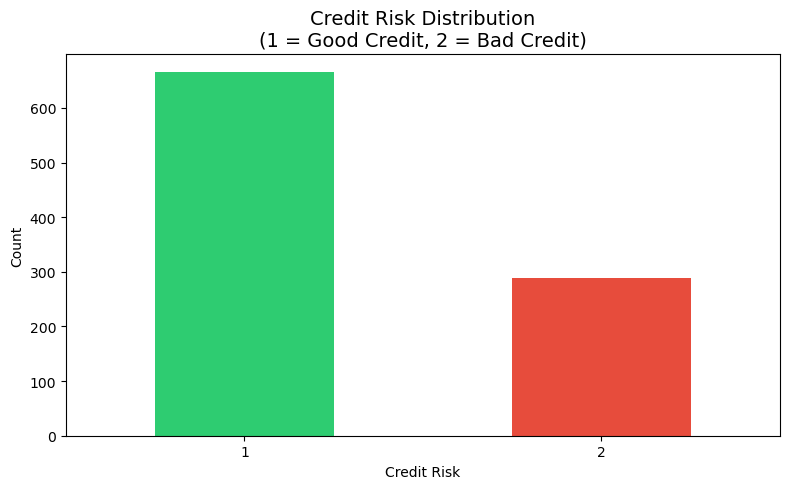

In [19]:
plt.figure(figsize=(8, 5))
df['Credit Risk'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Credit Risk Distribution\n(1 = Good Credit, 2 = Bad Credit)', fontsize=14)
plt.xlabel('Credit Risk')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('credit_risk_distribution.png', dpi=150)
plt.show()

In [20]:
print("\nNumeric Columns Summary:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(df[numeric_cols].describe())


Numeric Columns Summary:
              Age         Job  Credit amount    Duration  Credit Risk
count  954.000000  954.000000     954.000000  954.000000   954.000000
mean    35.501048    1.909853    3279.112159   20.780922     1.302935
std     11.379668    0.649681    2853.315158   12.046483     0.459768
min     19.000000    0.000000     250.000000    4.000000     1.000000
25%     27.000000    2.000000    1360.250000   12.000000     1.000000
50%     33.000000    2.000000    2302.500000   18.000000     1.000000
75%     42.000000    2.000000    3975.250000   24.000000     2.000000
max     75.000000    3.000000   18424.000000   72.000000     2.000000


In [21]:
print("\nCategorical Columns Value Counts:")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head(10))


Categorical Columns Value Counts:

Sex:
Sex
male      656
female    298
Name: count, dtype: int64

Housing:
Housing
own     680
rent    169
free    105
Name: count, dtype: int64

Saving accounts:
Saving accounts
little        576
moderate       96
quite rich     60
rich           47
Name: count, dtype: int64

Checking account:
Checking account
little      261
moderate    256
rich         59
Name: count, dtype: int64

Purpose:
Purpose
car                    322
radio/TV               262
furniture/equipment    175
business                93
education               58
repairs                 20
domestic appliances     12
vacation/others         12
Name: count, dtype: int64


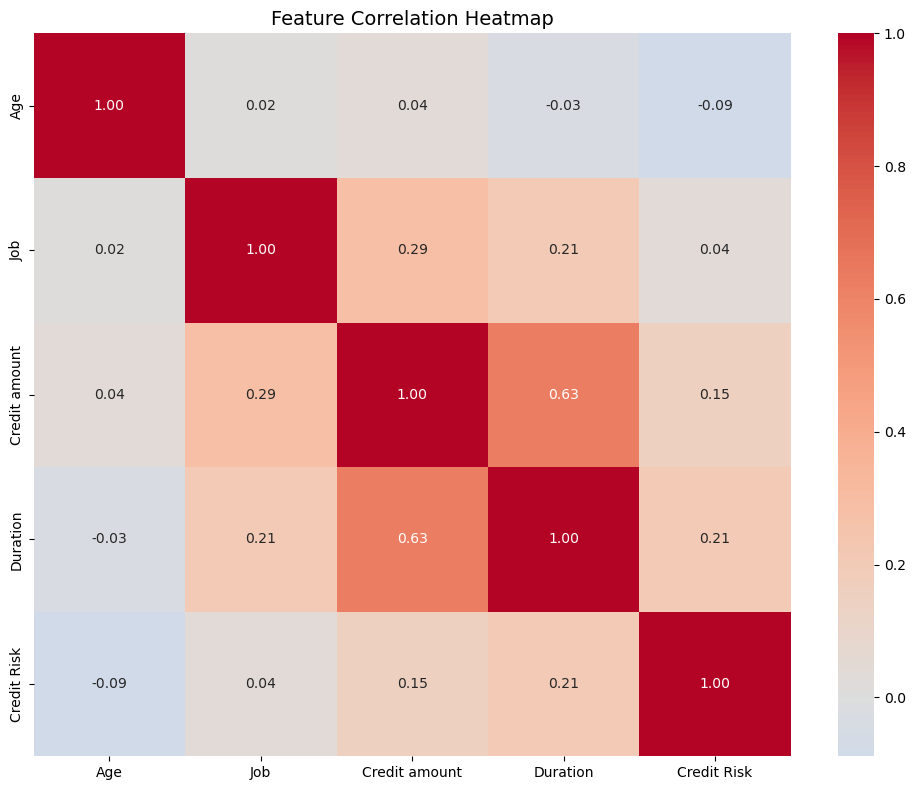

In [22]:
plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [23]:
print("\n" + "="*60)
print("DATA PREPROCESSING")
print("="*60)


DATA PREPROCESSING


In [24]:
df_processed = df.copy()

In [25]:
for col in categorical_cols:
    df_processed[col] = df_processed[col].fillna('unknown')

In [26]:
for col in numeric_cols:
    if col != 'Credit Risk':  # Don't fill target
        df_processed[col] = df_processed[col].fillna(df_processed[col].median())

In [27]:
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le

In [28]:
df_processed['credit_to_duration_ratio'] = df_processed['Credit amount'] / df_processed['Duration']
df_processed['is_young'] = (df_processed['Age'] < 30).astype(int)
df_processed['is_high_amount'] = (df_processed['Credit amount'] > df_processed['Credit amount'].quantile(0.75)).astype(int)
df_processed['is_long_duration'] = (df_processed['Duration'] > df_processed['Duration'].median()).astype(int)

In [29]:
print("New features created:")
print("- credit_to_duration_ratio")
print("- is_young")
print("- is_high_amount")
print("- is_long_duration")
print(f"\nTotal features: {df_processed.shape[1] - 1}")

New features created:
- credit_to_duration_ratio
- is_young
- is_high_amount
- is_long_duration

Total features: 13


In [30]:
X = df_processed.drop('Credit Risk', axis=1)
y = df_processed['Credit Risk']

In [31]:
y = y.apply(lambda x: 1 if x == 2 else 0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [32]:
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training set default rate: {y_train.mean():.3f}")
print(f"Test set default rate: {y_test.mean():.3f}")


Training set size: 763
Test set size: 191
Training set default rate: 0.303
Test set default rate: 0.304


In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
print("\n" + "="*60)
print("HANDLING CLASS IMBALANCE WITH SMOTE")
print("="*60)


HANDLING CLASS IMBALANCE WITH SMOTE


In [35]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE - Class distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"After SMOTE - Class distribution: {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE - Class distribution: {np.int64(0): np.int64(532), np.int64(1): np.int64(231)}
After SMOTE - Class distribution: {np.int64(0): np.int64(532), np.int64(1): np.int64(532)}


In [36]:
print("\n" + "="*60)
print("MODEL TRAINING & EVALUATION")
print("="*60)


MODEL TRAINING & EVALUATION


In [38]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate model performance with multiple metrics."""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob) if y_prob is not None else None
    }

    print(f"\n{'='*50}")
    print(f"MODEL: {model_name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {results['Accuracy']:.4f}")
    print(f"Precision: {results['Precision']:.4f}")
    print(f"Recall:    {results['Recall']:.4f}")
    print(f"F1-Score:  {results['F1-Score']:.4f}")
    if results['ROC-AUC']:
        print(f"ROC-AUC:   {results['ROC-AUC']:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Good Credit', 'Bad Credit']))

    return results, y_pred, y_prob

In [39]:
models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, max_depth=15),
    'XGBoost': XGBClassifier(n_estimators=200, random_state=RANDOM_STATE, eval_metric='logloss'),
    'SVM': SVC(probability=True, random_state=RANDOM_STATE, kernel='rbf')
}

In [40]:
all_results = []
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_resampled, y_train_resampled)
    results, y_pred, y_prob = evaluate_model(model, X_test_scaled, y_test, name)
    all_results.append(results)
    trained_models[name] = (model, y_pred, y_prob)


Training Logistic Regression...

MODEL: Logistic Regression
Accuracy:  0.7382
Precision: 0.5488
Recall:    0.7759
F1-Score:  0.6429
ROC-AUC:   0.7821

Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.88      0.72      0.79       133
  Bad Credit       0.55      0.78      0.64        58

    accuracy                           0.74       191
   macro avg       0.71      0.75      0.72       191
weighted avg       0.78      0.74      0.75       191


Training Decision Tree...

MODEL: Decision Tree
Accuracy:  0.6387
Precision: 0.4203
Recall:    0.5000
F1-Score:  0.4567
ROC-AUC:   0.6246

Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.76      0.70      0.73       133
  Bad Credit       0.42      0.50      0.46        58

    accuracy                           0.64       191
   macro avg       0.59      0.60      0.59       191
weighted avg       0.66      0.64      0.65       191


Trainin

In [41]:
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)


MODEL COMPARISON SUMMARY


In [42]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('ROC-AUC', ascending=False)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
                SVM  0.738220   0.557143 0.672414  0.609375 0.810345
Logistic Regression  0.738220   0.548780 0.775862  0.642857 0.782085
      Random Forest  0.722513   0.545455 0.517241  0.530973 0.779492
            XGBoost  0.712042   0.527273 0.500000  0.513274 0.736842
      Decision Tree  0.638743   0.420290 0.500000  0.456693 0.624579


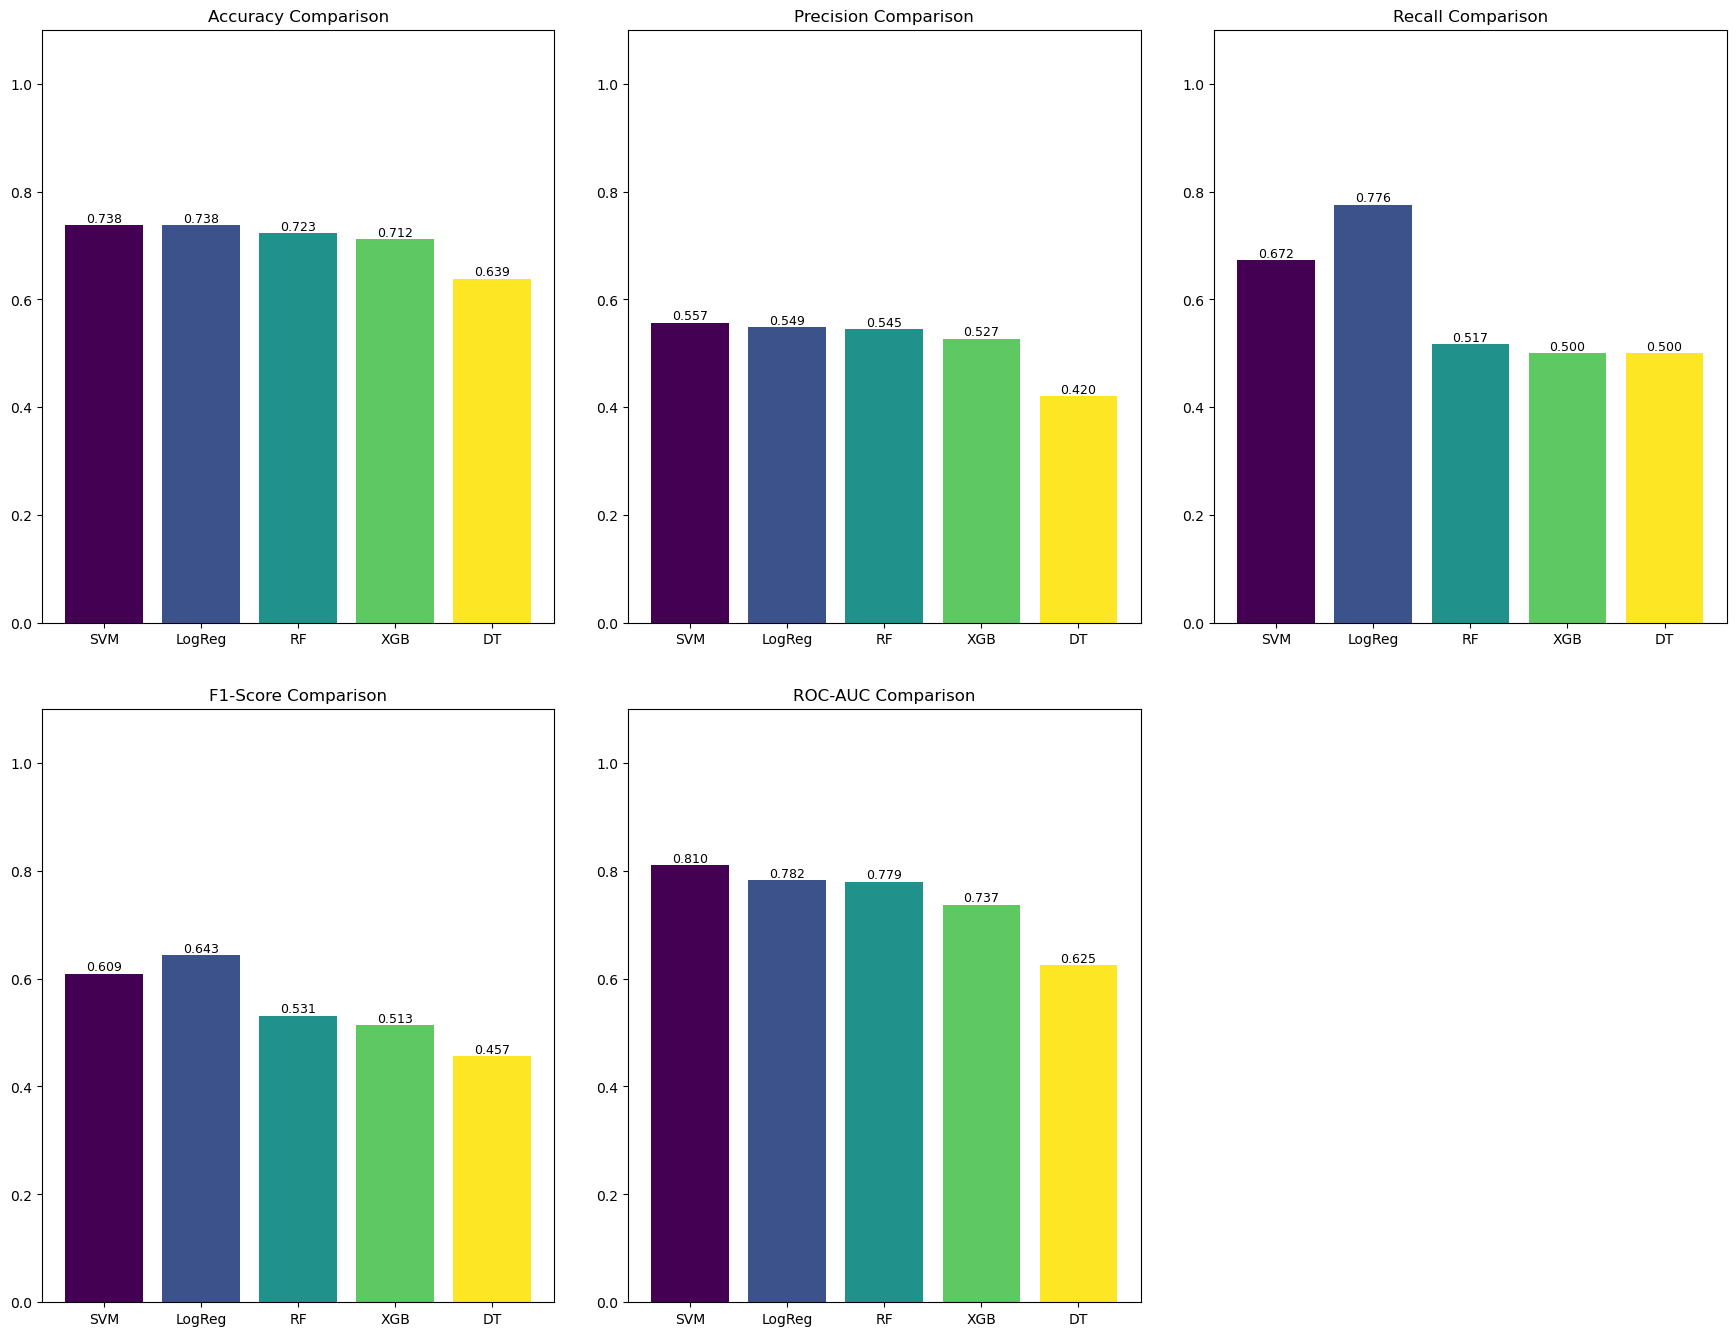

In [73]:
fig, axes = plt.subplots(2, 3, figsize=(18, 14))

# Shorten names for cleaner display
name_map = {
    'Logistic Regression': 'LogReg',
    'Random Forest': 'RF',
    'Decision Tree': 'DT',
    'XGBoost': 'XGB',
    'SVM': 'SVM'
}
results_df['Model'] = results_df['Model'].replace(name_map)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
for i, metric in enumerate(metrics):
    ax = axes.flatten()[i]
    bars = ax.bar(results_df['Model'], results_df[metric], 
                  color=plt.cm.viridis(np.linspace(0, 1, len(results_df))))
    ax.set_title(f'{metric} Comparison', fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', rotation=0)  # horizontal labels
    for bar in bars:
        height = bar.get_height()
        if height is not None and not np.isnan(height):
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Hide the 6th empty subplot
axes.flatten()[5].axis('off')

plt.tight_layout(pad=3.0)
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [51]:
best_model_name = results_df.iloc[0]['Model']
best_model, best_pred, _ = trained_models[best_model_name]

In [54]:
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[5])
axes[5].set_title(f'Confusion Matrix - {best_model_name}')
axes[5].set_xlabel('Predicted')
axes[5].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

<Figure size 640x480 with 0 Axes>

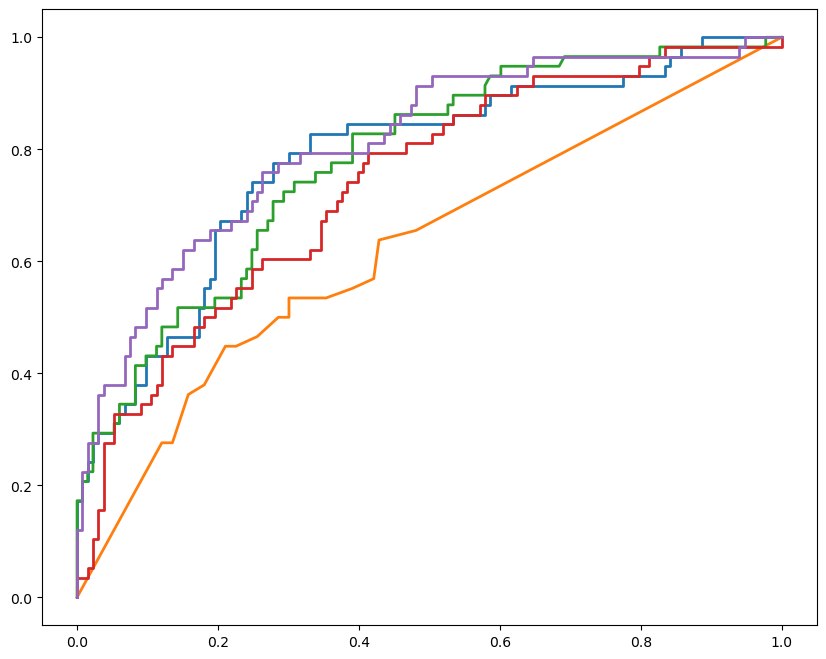

In [55]:
plt.figure(figsize=(10, 8))
for name, (model, _, y_prob) in trained_models.items():
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

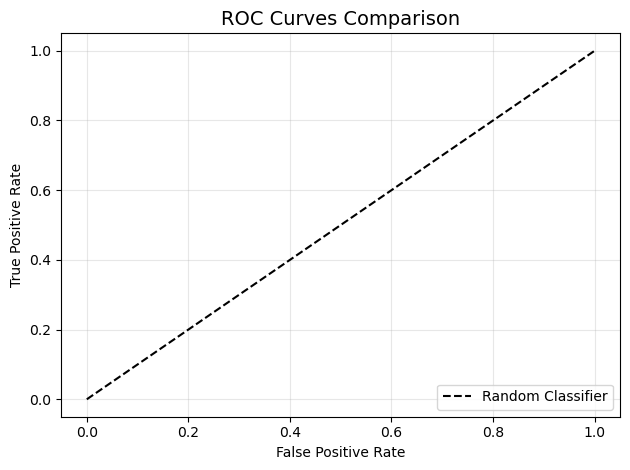

In [56]:
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

In [57]:
rf_model = trained_models['Random Forest'][0]
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

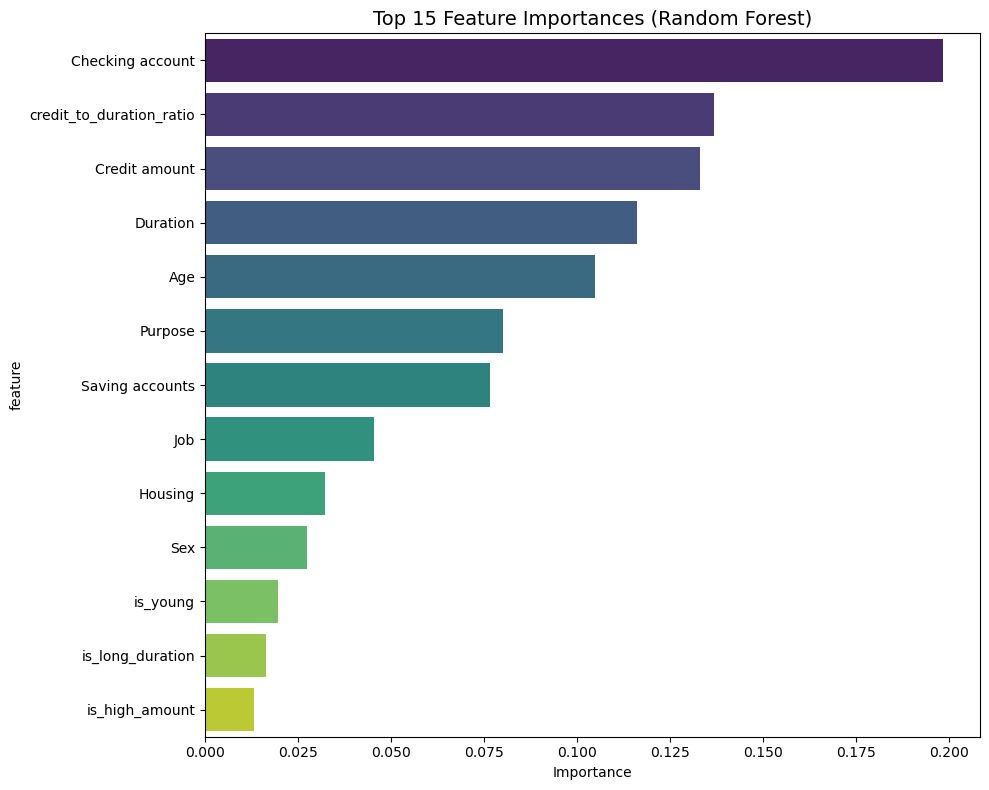

In [58]:
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14)
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [59]:
print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))


Top 10 Most Important Features:
                 feature  importance
        Checking account    0.198392
credit_to_duration_ratio    0.136909
           Credit amount    0.132940
                Duration    0.116105
                     Age    0.104838
                 Purpose    0.080013
         Saving accounts    0.076673
                     Job    0.045447
                 Housing    0.032232
                     Sex    0.027351


In [60]:
print("\n" + "="*60)
print("HYPERPARAMETER TUNING - XGBOOST")
print("="*60)


HYPERPARAMETER TUNING - XGBOOST


In [61]:
param_grid_small = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1]
}

In [62]:
print("Running Grid Search (this may take a few minutes)...")
grid_search = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
    param_grid_small,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

Running Grid Search (this may take a few minutes)...


In [63]:
grid_search.fit(X_train_resampled, y_train_resampled)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation ROC-AUC: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best Cross-Validation ROC-AUC: 0.8774


In [64]:
best_tuned_model = grid_search.best_estimator_
tuned_results, tuned_pred, tuned_prob = evaluate_model(
    best_tuned_model, X_test_scaled, y_test, "Tuned XGBoost"
)


MODEL: Tuned XGBoost
Accuracy:  0.6806
Precision: 0.4727
Recall:    0.4483
F1-Score:  0.4602
ROC-AUC:   0.7337

Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.76      0.78      0.77       133
  Bad Credit       0.47      0.45      0.46        58

    accuracy                           0.68       191
   macro avg       0.62      0.62      0.62       191
weighted avg       0.68      0.68      0.68       191



In [65]:
import joblib

joblib.dump(best_tuned_model, 'credit_scoring_model.pkl')
joblib.dump(scaler, 'credit_scaler.pkl')
joblib.dump(label_encoders, 'credit_label_encoders.pkl')

print("\n" + "="*60)
print("MODEL SAVED SUCCESSFULLY!")
print("="*60)
print("Files saved:")
print("- credit_scoring_model.pkl (Trained Model)")
print("- credit_scaler.pkl (Feature Scaler)")
print("- credit_label_encoders.pkl (Label Encoders)")
print("- credit_risk_distribution.png")
print("- correlation_heatmap.png")
print("- model_comparison.png")
print("- roc_curves.png")
print("- feature_importance.png")


MODEL SAVED SUCCESSFULLY!
Files saved:
- credit_scoring_model.pkl (Trained Model)
- credit_scaler.pkl (Feature Scaler)
- credit_label_encoders.pkl (Label Encoders)
- credit_risk_distribution.png
- correlation_heatmap.png
- model_comparison.png
- roc_curves.png
- feature_importance.png


In [66]:
def predict_credit_risk(new_data_dict):

    input_df = pd.DataFrame([new_data_dict])

    
    for col in categorical_cols:
        if col in input_df.columns:
            le = label_encoders[col]
          
            input_df[col] = input_df[col].apply(
                lambda x: x if x in le.classes_ else le.classes_[0]
            )
            input_df[col] = le.transform(input_df[col].astype(str))

    
    input_df['credit_to_duration_ratio'] = input_df['Credit amount'] / input_df['Duration']
    input_df['is_young'] = (input_df['Age'] < 30).astype(int)
    input_df['is_high_amount'] = (input_df['Credit amount'] > 5000).astype(int)
    input_df['is_long_duration'] = (input_df['Duration'] > 24).astype(int)

    
    input_df = input_df[X.columns]

    
    input_scaled = scaler.transform(input_df)

    
    probability = best_tuned_model.predict_proba(input_scaled)[0][1]
    prediction = best_tuned_model.predict(input_scaled)[0]

    risk_level = "HIGH RISK" if probability > 0.7 else "MEDIUM RISK" if probability > 0.4 else "LOW RISK"

    return {
        'default_probability': round(probability, 4),
        'prediction': 'Bad Credit' if prediction == 1 else 'Good Credit',
        'risk_level': risk_level,
        'recommendation': 'Reject' if prediction == 1 else 'Approve'
    }


In [67]:
print("\n" + "="*60)
print("EXAMPLE PREDICTION")
print("="*60)


EXAMPLE PREDICTION


In [68]:
sample_applicant = {
    'Age': 35,
    'Sex': 'male',
    'Job': 2,
    'Housing': 'own',
    'Saving accounts': 'little',
    'Checking account': 'moderate',
    'Credit amount': 5000,
    'Duration': 24,
    'Purpose': 'car'
}

In [71]:
result = predict_credit_risk(sample_applicant)
print(f"\nApplicant: Age 35, Male, Credit $5000, 24 months")
print(f"Prediction: {result['prediction']}")
print(f"Default Probability: {result['default_probability']}")
print(f"Risk Level: {result['risk_level']}")
print(f"Recommendation: {result['recommendation']}")


Applicant: Age 35, Male, Credit $5000, 24 months
Prediction: Good Credit
Default Probability: 0.42649999260902405
Risk Level: MEDIUM RISK
Recommendation: Approve
